In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [51]:
#Read Data
df=pd.read_csv('https://raw.githubusercontent.com/campusx-official/jupyter-masterclass/main/tweet_emotions.csv')
df.head(2)

,tweet_id,sentiment,content
0,1956967341,empty,@tiffanylue i know i was listenin to bad habi...
1,1956967666,sadness,Layin n bed with a headache ughhhh...waitin o...


In [52]:
df.drop(inplace=True,columns='tweet_id')

In [5]:
#Total Records
df.shape[0]

40000

In [6]:
#Check Missing Values
df.isnull().sum()

sentiment    0
content      0
dtype: int64

In [7]:
#Check Col Dtypes
df.dtypes

sentiment    object
content      object
dtype: object

In [8]:
#List Of All Columns
df.columns

Index(['sentiment', 'content'], dtype='object')

In [53]:
#Check Duplicate Record
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [11]:
#no. Of unique values In each Col
df.nunique()

sentiment       13
content      39827
dtype: int64

Text(0.5, 1.0, 'Text vs Sentiment')

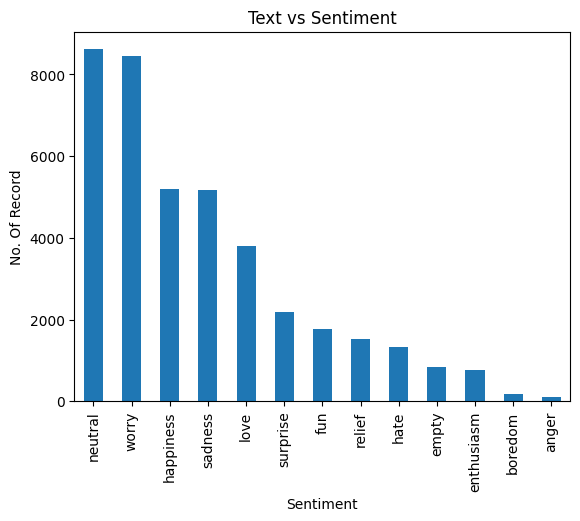

In [15]:
df.sentiment.value_counts().plot(kind='bar')
plt.xlabel('Sentiment')
plt.ylabel('No. Of Record')
plt.title('Text vs Sentiment')

In [54]:
#Custom Col
df['no_of_char']=df.content.apply(lambda x:len(x))
df['no_of_word']=df.content.apply(lambda x:len(x.split()))


In [39]:
df.sentiment.unique()

array(['empty', 'sadness', 'enthusiasm', 'neutral', 'worry', 'surprise',
       'love', 'fun', 'hate', 'happiness', 'boredom', 'relief', 'anger'],
      dtype=object)

In [40]:
map={}
enc=0
for i in df.sentiment.unique():
    map[i]=enc
    enc+=1
print(map)

{'empty': 0, 'sadness': 1, 'enthusiasm': 2, 'neutral': 3, 'worry': 4, 'surprise': 5, 'love': 6, 'fun': 7, 'hate': 8, 'happiness': 9, 'boredom': 10, 'relief': 11, 'anger': 12}


In [ ]:
df['sentiment_enc']=df.sentiment.map(map)

In [43]:
df

,sentiment,content,no_of_char,no_of_word
0,0,@tiffanylue i know i was listenin to bad habi...,92,18
1,1,Layin n bed with a headache ughhhh...waitin o...,60,10
2,1,Funeral ceremony...gloomy friday...,35,3
3,2,wants to hang out with friends SOON!,36,7
4,3,@dannycastillo We want to trade with someone w...,86,15
...,...,...,...,...
39995,3,@JohnLloydTaylor,16,1
39996,6,Happy Mothers Day All my love,30,6
39997,6,Happy Mother's Day to all the mommies out ther...,123,25
39998,9,@niariley WASSUP BEAUTIFUL!!! FOLLOW ME!! PEE...,122,19


8


<Axes: >

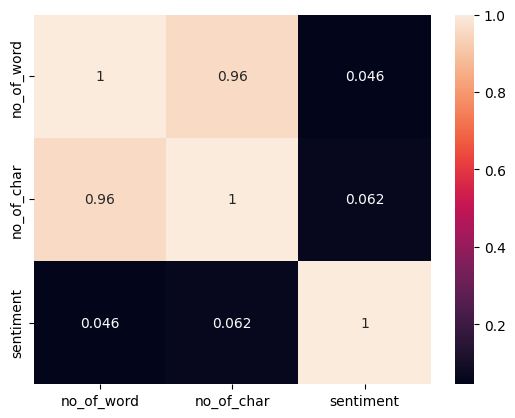

In [ ]:
#Heatmap
sns.heatmap(data=df[['no_of_word','no_of_char','sentiment_enc']].corr(),annot=True)

In [55]:
df.drop(columns=['no_of_word'],inplace=True)
df.head()

,sentiment,content,no_of_char
0,empty,@tiffanylue i know i was listenin to bad habi...,92
1,sadness,Layin n bed with a headache ughhhh...waitin o...,60
2,sadness,Funeral ceremony...gloomy friday...,35
3,enthusiasm,wants to hang out with friends SOON!,36
4,neutral,@dannycastillo We want to trade with someone w...,86


In [57]:
df.to_csv('../data/raw/raw_data.csv')